In [ ]:
'''
Kind of a 'reduced' model, where the noise is added as a stochastic term, by computing approximate influences random values 
of x,y,and z have on T and S, and allowing for the drawing of additive and multiplicative noise terms from this calculation,
without the atmosphere. 
The drift terms are used for correction, the variances are used as noise amplitudes, and the noise term is drawn 
from A guassian distribution with the covariance of T and S caluclated.
Tsurf and Ssurf are statistically averaged out and replaced with their net effect, the drift terms cT and cS-> I think I still 
need to keep theta0, theta1 and sigma0 and sigma1.
'''

In [20]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
zeros = pd.read_csv('../data/cov_matrix.csv')

In [22]:
def smoothabs(x, xi=10000):
    """Smooth absolute value function"""
    return x * np.tanh(x * xi)

In [102]:
def get_noise(t0):
    # pull the numbers that correspond to the current initial condition t0
    row       = zeros.loc[zeros['t0'] == t0].iloc[0]
    #print("row:",row)
    cov,vT,vS  = row['corr_TS'],row['sigma_T'],row['sigma_S']
    #noise amplitude is vT and vS, then random noises are correlated by cov
    z = np.random.randn(2)
    dW = np.sqrt(dt_slow) * z                 # Brownian increments
    x1 = vT * dW[0]
    x2 = vS * (cov * z[0] + np.sqrt(max(0,1-cov**2)) * z[1]) * np.sqrt(dt_slow)
    #plt.plot(x1)
    #plt.plot(x2)
    #print("x1:",x1,"x2:",x2)
    
    return x1,x2
    

In [103]:
x1s=[]
x2s=[]
def gottwald_noice(t,state,t0,params):
    """Gottwald model functions without sea ice"""
    mu = 7.5
    epsilon_a = 0.34
    dt_slow=0.025
    x_avg=1.0147
    delta_avg=1.7463
    sigma_1=0.00934
    sigma_0 = 0.9
    theta_0=1
    theta_1=0.0195
    #print('state at first:',state)
    if np.isnan(state).any():
        state = np.array([0, 0])

    T, S = state
    #print("state:",T,S)

    row          = zeros.loc[zeros['t0'] == t0].iloc[0]
    x_avg_corr,delta_avg_corr  = row['x_avg_corr'], row['delta_avg_corr']
    sigma_T,sigma_S = row['sigma_T'],row['sigma_S']
    
    #Delta = y**2 + z**2
    #T_surf = theta_0 + theta_1 * x_avg_corr
    #S_surf = sigma_0 + sigma_1 * delta_avg_corr
    x1,x2=get_noise(0)
    #print("x1 and x2:",x1,',',x2)

    dT_det = -1/epsilon_a*(T-(theta_0 + x_avg_corr)) - T - mu*smoothabs(S - T)*T 
    dS_det =  - S - mu*smoothabs(S - T)*S + sigma_0 + delta_avg_corr
    #plt.plot(x1,x2)
    #for i in range(10):
    T += dT_det *dt_slow + x1   # add correlated noise
    S += dS_det *dt_slow + x2
    x1s.append(x1)
    x2s.append(x2)

    
    empirical_var = np.var(x1s, ddof=0) 
    expected_per_step = sigma_T**2 * dt_slow 
    #print(empirical_var, expected_per_step, empirical_var/expected_per_step)
    
    #dx = 1/epsilon_f*(-Delta - a*(x - F0 - F1*T))
    #dy = 1/epsilon_f*(x*y - b*x*z - (y - G0 + G1*T))
    #dz = 1/epsilon_f*(b*x*y + x*z - z)
    #dT = -1/epsilon_a*(T - T_surf) - T - mu*smoothabs(S-T)*T + np.random.uniform(0,1)*TS_corr*sigma_T
    #dS = S_surf - S - mu*smoothabs(S-T)*S + np.random.uniform(0,1)*TS_corr*sigma_S
    
    return np.array([T, S])

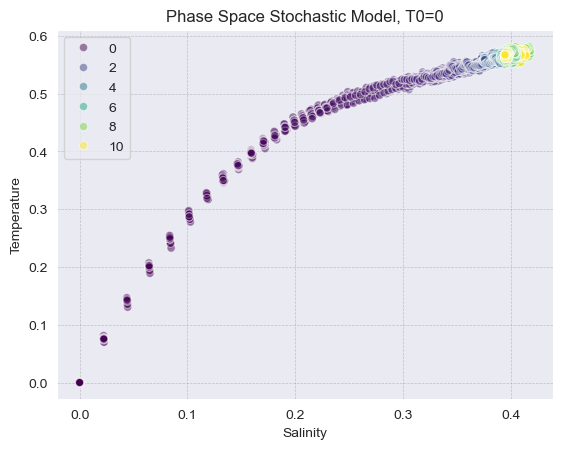

In [104]:
T0=0.
S0=0
state0 = np.array([T0, S0])
solution=[]
solution.append(state0)
T_final = 10.0     # final simulation time
dt_slow = 0.025    
t_eval = np.arange(0, T_final + dt_slow, dt_slow)
ntrajs=20
all_trajs = np.zeros((ntrajs, len(t_eval), 2))

for j in range(ntrajs):
    state = np.array([T0, S0], dtype=float)
    all_trajs[j, 0, :] = state
    for i, t in enumerate(t_eval[1:], start=1):
        state = gottwald_noice(t, state=state, t0=T0, params=None)  # ensure this returns only state
        all_trajs[j, i, :] = state
        #print(solution)

ntrajs, nsteps, _ = all_trajs.shape
traj_idx = np.repeat(np.arange(ntrajs), nsteps)
time_idx = np.tile(t_eval, ntrajs)
T_vals   = all_trajs[:,:,0].ravel()
S_vals   = all_trajs[:,:,1].ravel()

df = pd.DataFrame({
        'traj': traj_idx,
        'time': time_idx,
        'T': T_vals,
        'S': S_vals
})
    

sol = np.array(solution)  # shape: (len(t_eval), 2)

plt.figure()

ax = plt.gca()
#no_transient=df.loc[df['time']>0.7]
# faint background line for context
#sns.lineplot(data=no_transient,x='S', y='T',
        #color="#d9d9d9", linewidth=1.0, zorder=1)

# colored instanton / trajectory gradient by time (use a numeric column, e.g. Year)
#sc = ax.scatter(no_transient['S'], no_transient['T'],
               # c=no_transient['time'], cmap='plasma', s=40, zorder=2)
sns.scatterplot(data=df, x='S', y='T', hue='time',
         palette='viridis',  linewidth=0.8, alpha=0.5, ax=ax)
mean_df = df.groupby('time')[['T','S']].mean().reset_index()
#sns.lineplot(data=mean_df, x='S', y='T', color='C0', linewidth=2, ax=ax)
#cbar = plt.colorbar(sc, ax=ax)
#cbar.set_label('Year')

# grid on
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.4)

plt.title(f"Phase Space Stochastic Model, T0=0")
plt.xlabel('Salinity')
plt.ylabel('Temperature')
ax.legend()

#if (file=='salt_40y_200traj_7000k.csv'):
#plt.savefig(f"edge_instanton_salinity_{traj}{seed}.png")
plt.show()
#plt.close() 


In [117]:
def paths_t0s(t0):
    T0=t0
    S0=0
    state0 = np.array([T0, S0])
    solution=[]
    solution.append(state0)
    T_final = 40.0     # final simulation time
    dt_slow = 0.025    
    t_eval = np.arange(0, T_final + dt_slow, dt_slow)
    ntrajs=100
    all_trajs = np.zeros((ntrajs, len(t_eval), 2))
    
    for j in range(ntrajs):
        state = np.array([T0, S0], dtype=float)
        all_trajs[j, 0, :] = state
        for i, t in enumerate(t_eval[1:], start=1):
            state = gottwald_noice(t, state=state, t0=T0, params=None)  # ensure this returns only state
            all_trajs[j, i, :] = state
            #print(solution)
    
    ntrajs, nsteps, _ = all_trajs.shape
    traj_idx = np.repeat(np.arange(ntrajs), nsteps)
    time_idx = np.tile(t_eval, ntrajs)
    T_vals   = all_trajs[:,:,0].ravel()
    S_vals   = all_trajs[:,:,1].ravel()
    
    df = pd.DataFrame({
        'traj': traj_idx,
        'time': time_idx,
        'T': T_vals,
        'S': S_vals
    })
    print("T0:",t0," finished.")
        
    return df
'''
    #plt.figure()
    
    #ax = plt.gca()
    #no_transient=df.loc[df['time']>10]
    # faint background line for context
    #sns.lineplot(data=no_transient,x='S', y='T',
            #color="#d9d9d9", linewidth=1.0, zorder=1)

    
    # colored instanton / trajectory gradient by time (use a numeric column, e.g. Year)
    #sc = ax.scatter(no_transient['S'], no_transient['T'],
                   # c=no_transient['time'], cmap='plasma', s=40, zorder=2)
    #sns.scatterplot(data=no_transient, x='S', y='T', hue='time',
     #        palette='plasma', legend=False, linewidth=0.8, alpha=0.25, ax=ax)
    mean_df = no_transient.groupby('time')[['T','S']].mean().reset_index()
    sns.lineplot(data=mean_df, x='S', y='T', color='C0', linewidth=2, ax=ax)
    #cbar = plt.colorbar(sc, ax=ax)
    #cbar.set_label('Year')
    
    # grid on
    ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.4)
    
    plt.title(f"Phase Space Stochastic Model, T0={t0}")
    plt.xlabel('Salinity')
    plt.ylabel('Temperature')
    ax.legend()
    
    #if (file=='salt_40y_200traj_7000k.csv'):
    #plt.savefig(f"edge_instanton_salinity_{traj}{seed}.png")
    plt.show()
    #plt.close() 
    '''
 

'\n    #plt.figure()\n    \n    #ax = plt.gca()\n    #no_transient=df.loc[df[\'time\']>10]\n    # faint background line for context\n    #sns.lineplot(data=no_transient,x=\'S\', y=\'T\',\n            #color="#d9d9d9", linewidth=1.0, zorder=1)\n\n    \n    # colored instanton / trajectory gradient by time (use a numeric column, e.g. Year)\n    #sc = ax.scatter(no_transient[\'S\'], no_transient[\'T\'],\n                   # c=no_transient[\'time\'], cmap=\'plasma\', s=40, zorder=2)\n    #sns.scatterplot(data=no_transient, x=\'S\', y=\'T\', hue=\'time\',\n     #        palette=\'plasma\', legend=False, linewidth=0.8, alpha=0.25, ax=ax)\n    mean_df = no_transient.groupby(\'time\')[[\'T\',\'S\']].mean().reset_index()\n    sns.lineplot(data=mean_df, x=\'S\', y=\'T\', color=\'C0\', linewidth=2, ax=ax)\n    #cbar = plt.colorbar(sc, ax=ax)\n    #cbar.set_label(\'Year\')\n    \n    # grid on\n    ax.grid(color=\'gray\', linestyle=\'--\', linewidth=0.5, alpha=0.4)\n    \n    plt.title(f"Phase Sp

In [118]:
df_this = paths_t0s(0)

KeyboardInterrupt: 

In [92]:
df_this.head()

,traj,time,T,S
0,0,0.000,0.000000,0.000000
1,0,0.025,0.070969,0.022604
2,0,0.050,0.133959,0.044452
3,0,0.075,0.192321,0.065074
4,0,0.100,0.238272,0.084579


/var/folders/v1/ymptnwwx3x1b7_mw0nns09wr0000gn/T/ipykernel_62780/948636032.py:4: UserWarning: 
The palette list has fewer values (6) than needed (100) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(


<Axes: xlabel='time', ylabel='T'>

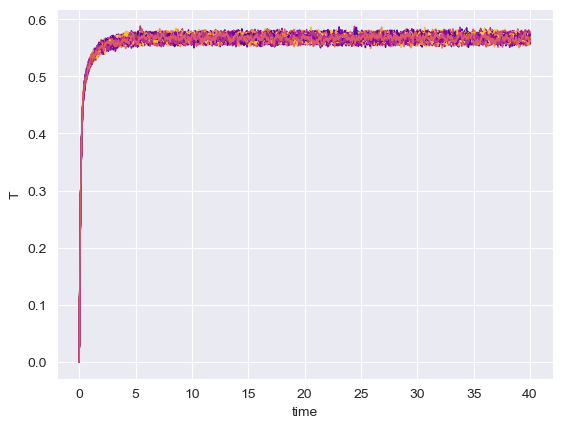

In [111]:

plt.figure()
#Lineplot
sns.set_style("darkgrid")
sns.lineplot(
    data=df_this,
    x="time",
    y="T",
    hue="traj",
    estimator=None,          #prevents averaging / collapsing
    lw=1,
    palette=sns.color_palette("plasma"),
    legend=False)

In [ ]:
t0_dict={}
for t0 in zeros['t0'].unique().tolist():
    t0_data=paths_t0s(t0)
    t0_dict[t0]=t0_data

T0: 0.0  finished.


In [95]:
#means of T and S, d model
print(df_this['T'].mean())
print(df_this['S'].mean())
#variance of S and T
print(df_this['T'].var())
print(df_this['S'].var())
#covariance
cov_TS = ((df_this['T'] - df_this['S'].mean()) * df_this['T'] - df_this['S'].mean()).mean() 
print(cov_TS)

0.5668392653037322
0.40081021491854874
5.641391857131797e-05
7.639956296097326e-05
-0.3066420162015951


(array([1.0000e+01, 1.0000e+01, 1.0000e+01, 1.0000e+01, 1.7000e+01,
        1.5000e+01, 3.0000e+01, 6.4000e+01, 2.7400e+02, 3.9957e+05]),
 array([0.        , 0.05867843, 0.11735686, 0.17603529, 0.23471372,
        0.29339215, 0.35207058, 0.41074901, 0.46942744, 0.52810587,
        0.5867843 ]),
 <BarContainer object of 10 artists>)

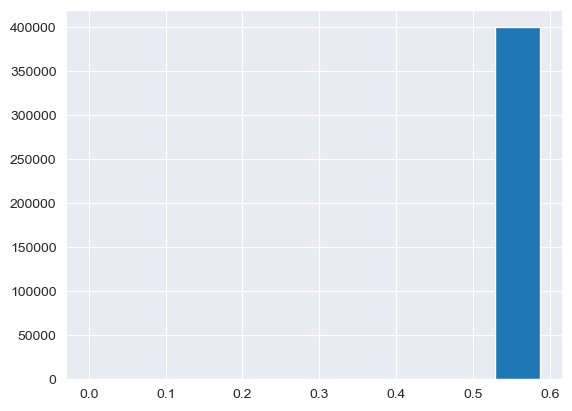

In [96]:
plt.hist(df_this['T'])

(array([2.00000e+01, 3.00000e+01, 2.00000e+01, 3.10000e+01, 4.90000e+01,
        7.00000e+01, 1.14000e+02, 1.97000e+02, 5.54000e+02, 3.98925e+05]),
 array([0.        , 0.04239847, 0.08479694, 0.12719541, 0.16959388,
        0.21199234, 0.25439081, 0.29678928, 0.33918775, 0.38158622,
        0.42398469]),
 <BarContainer object of 10 artists>)

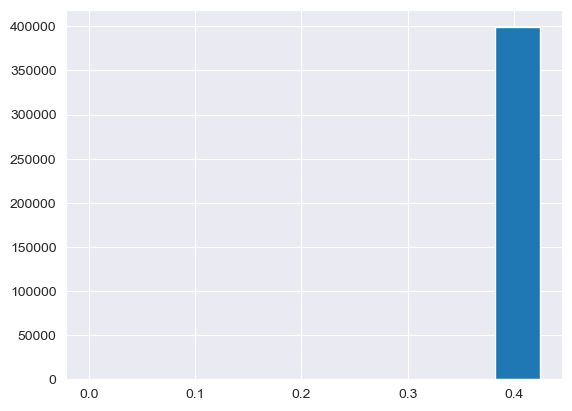

In [97]:
plt.hist(df_this['S'])

In [225]:
def autocorrelation(var):
    target_list = np.array(var)
    print(len(target_list))
    num_slices = 100
    slice_length = len(target_list) // num_slices
    
    #Split series into slices
    slices = np.array_split(target_list, num_slices)
    
    #Initialize array to store ACF for each slice
    expectations = np.zeros((num_slices, slice_length))
    
    for slice_num, s in enumerate(slices):
        s = np.array(s)
        mean_s = np.mean(s)
        var_s = np.var(s)
    
        #Compute autocovariance for each lag
        for lag in range(slice_length):
            #Take all overlapping pairs at this lag, s[:len(s)-lag] -> all except last values, (s[lag:]) -> all except first vals
            products = (s[:len(s)-lag] - mean_s) * (s[lag:] - mean_s)
            expectations[slice_num, lag] = np.mean(products) / var_s 
    
    #Average ACF across slices
    ACF = np.mean(expectations, axis=0)
    
    return ACF

401


Text(0, 0.5, 'Auto-correlation')

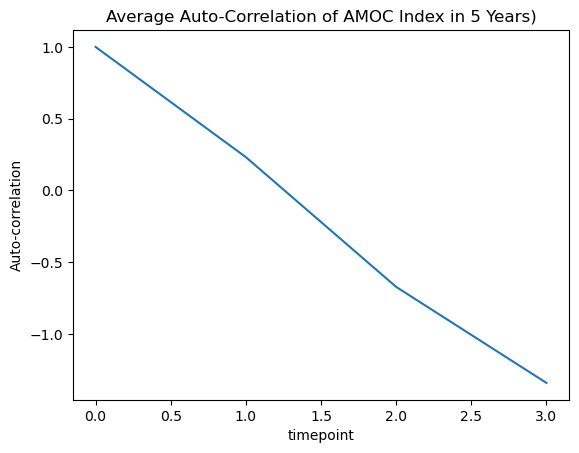

In [226]:
#plot autocorrelation function
#title_var = slice_length/10
ACF_s = autocorrelation(sol[:,1])
plt.figure()
plt.plot(ACF_s)
plt.title(f"Average Auto-Correlation of AMOC Index in 5 Years)")
plt.xlabel('timepoint')
plt.ylabel('Auto-correlation')
#plt.savefig('acfunc_salt.png')

401


Text(0, 0.5, 'Auto-correlation')

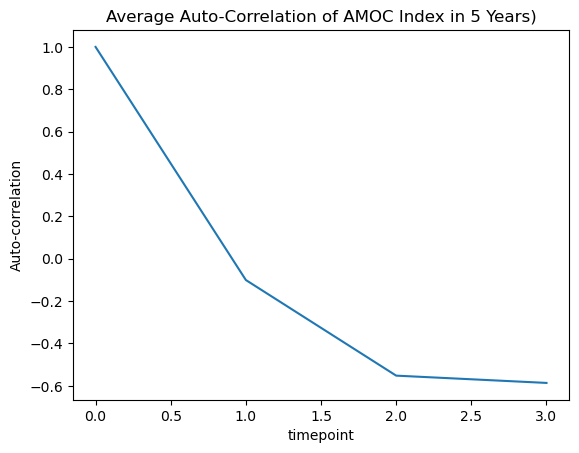

In [227]:
#plot autocorrelation function
#title_var = slice_length/10
ACF_t = autocorrelation(sol[:,0])
plt.figure()
plt.plot(ACF_t)
plt.title(f"Average Auto-Correlation of AMOC Index in 5 Years)")
plt.xlabel('timepoint')
plt.ylabel('Auto-correlation')
#plt.savefig('acfunc_salt.png')